In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision

import matplotlib.pyplot as plt
from tqdm import tqdm
import math

In [2]:
transform = transforms.Compose([
  transforms.Resize((128, 128)),
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,)) 
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size=64
epochs=5
autoencoder_epochs=1
n_workers=4

In [3]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=n_workers) 

In [4]:
class Encoder(nn.Module):
  def __init__(self,dim=128):
    super().__init__()
    self.conv=nn.Sequential(
      nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
      nn.MaxPool2d(2,2), #B,32,64,64,
      nn.ReLU(),
      nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
      nn.MaxPool2d(2,2), #B,64,32,32
      nn.ReLU(),
      nn.Conv2d(64,dim, kernel_size=3, stride=1, padding=1),
      nn.MaxPool2d(2,2), #B,dim,16,16
      nn.ReLU(),
    )
  
  def forward(self,x):
    x = self.conv(x) #B,dim,16,16
    x_shape = x.size()
    x = x.view(x_shape[0], x_shape[1], -1) #B,dim,256
    x = x.permute(0,2,1) #B,256,dim
    return x

class BlenderInternals(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.dim=dim
    self.prompt_embed=nn.Embedding(10, dim) #B,dim
    self.prompt_unembed=nn.Linear(dim,1)
    self.timestep_fc = nn.Linear(dim,dim)

    self.image_q = nn.Linear(dim, dim)
    self.image_v = nn.Linear(dim, dim)
    self.image_k = nn.Linear(dim, dim)
    
    self.prompt_q = nn.Linear(dim, dim)
    self.prompt_v = nn.Linear(dim, dim)
    self.prompt_k = nn.Linear(dim, dim)

  def timestep_embedding(self, t):
    # Create a sinusoidal embedding for the time step
    half_dim = self.dim // 2
    emb = torch.exp(torch.arange(half_dim, device=t.device) * -(torch.log(torch.tensor(10000.0)) / half_dim))
    emb = t[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    emb = emb.reshape(emb.size(0),-1)
    #print(f"emb shape: {emb.shape}")
    return self.timestep_fc(emb) #B,dim

  def embed_prompt(self,prompt):
    prompt = prompt.unsqueeze(-1)
    prompt = self.prompt_embed(prompt)
    return prompt

  def forward(self, image, prompt, timestep):
    # print(f"blenderinternals start fwd: {image.shape}, {prompt.shape}, {timestep.shape}")
    #image shape: B,256,dim-> B,T,C
    #prompt shape: B,1,dim
    #timestep shape: B,1
    timestep = self.timestep_embedding(timestep) #B,dim
    timestep = self.timestep_fc(timestep) #B,dim
    timestep = timestep.unsqueeze(1) #B,1,dim

    # prompt = prompt.unsqueeze(-1) #B,1,1
    # prompt = self.prompt_embed(prompt) #B,1,dim
    #prompt embedding assumed
   
    # print(f"shapes: t {timestep.shape}, i {image.shape}, p {prompt.shape}")
    image = image+timestep #B,1,dim
    prompt=prompt+timestep #B,256,dim
     
    image_q = self.image_q(image) #B,256,dim
    image_k = self.image_k(image) #B,256,dim
    image_v = self.image_v(image) #B,256,dim
    
    prompt_q = self.prompt_q(prompt) #B,1,dim
    prompt_k = self.prompt_k(prompt) #B,1,dim
    prompt_v = self.prompt_v(prompt) #B,1,dim

    Q = torch.cat([image_q, prompt_q], dim=1) #B,257,dim
    K = torch.cat([image_k, prompt_k], dim=1) #B,257,dim
    V = torch.cat([image_v, prompt_v], dim=1) #B,257,dim

    # print(f"before sdpa {Q.shape}, {K.shape}, {V.shape}")
    out = F.scaled_dot_product_attention(Q,K,V) #B,257,dim
    out_image = out[:,:-1,:]
    out_prompt=out[:,-1,:]

    # out_prompt = self.prompt_unembed(out_prompt)
    out_prompt = out_prompt.unsqueeze(1)
    # print(f"after all",out_image.shape, out_prompt.shape)
    return out_image,out_prompt

class Decoder(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.decoder = nn.Sequential(
      # 16x16 -> 32x32
      nn.ConvTranspose2d(dim, dim // 2, kernel_size=4, stride=2, padding=1),
      nn.BatchNorm2d(dim // 2),
      nn.ReLU(inplace=True),

      # 32x32 -> 64x64
      nn.ConvTranspose2d(dim // 2, dim // 4, kernel_size=4, stride=2, padding=1),
      nn.BatchNorm2d(dim // 4),
      nn.ReLU(inplace=True),

      # 64x64 -> 128x128
      nn.ConvTranspose2d(dim // 4, dim // 8, kernel_size=4, stride=2, padding=1),
      nn.BatchNorm2d(dim // 8),
      nn.ReLU(inplace=True),

      # Final projection to 1 channel
      nn.Conv2d(dim // 8, 1, kernel_size=3, padding=1),
      # nn.Sigmoid()
    )

  def forward(self, x):
    """
    x: (B, L, D)
    """
    B, L, D = x.shape
    H = W = int(math.sqrt(L))
    assert H * W == L, "L must be a perfect square"

    # (B, L, D) -> (B, D, H, W)
    x = x.permute(0, 2, 1).contiguous()
    x = x.view(B, D, H, W)

    x = self.decoder(x)
    return x

class BlenderV2(nn.Module):
  def __init__(self, dim, num_layers):
    super().__init__()
    
    self.encoder = Encoder(dim)
    self.blenderhead = BlenderInternals(dim)
    self.blenderinternals = nn.ModuleList([BlenderInternals(dim) for _ in range(num_layers-1)])
    self.decoder = Decoder(dim)

  def encode(self,image):
    x = self.encoder(image)
    return x
  
  def decode(self,x):
    x = self.decoder(x)
    return x
  
  def forward(self,image, prompt, timestep):
    image = self.encode(image)
    prompt = self.blenderhead.embed_prompt(prompt)

    res_img = image
    res_prompt = prompt
    image, prompt = self.blenderhead(image, prompt, timestep)
    image = image+res_img
    prompt = prompt+res_prompt

    for i in range(len(self.blenderinternals)):
      res_img = image
      res_prompt = prompt
      image, prompt= self.blenderinternals[i](image, prompt, timestep)
      image = image+res_img
      prompt = prompt+res_prompt
    return image

In [5]:
# model= Blender(dim=1024).to(torch.float32)
# model=StackedBlender(dim=1024, num_layers=8).to(torch.float32)
model=BlenderV2(dim=128, num_layers=2)

In [6]:
model = model.to(device)
torch.set_float32_matmul_precision("high")
compiled_model = torch.compile(model)
# compiled_model=model
optimizer = optim.Adam(lr=1e-4, params=model.parameters())

pbar_ae = tqdm(total=len(dataloader) * autoencoder_epochs, ncols=100)

print("training ae")
for epoch in range(autoencoder_epochs):
  for count, (image, _) in enumerate(dataloader):

    image = image.to(device)
    image_original = image
    image = model.encoder(image)
    image = model.decoder(image)

    loss = F.mse_loss(image, image_original)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    pbar_ae.update(1)
    pbar_ae.set_postfix({"loss": f"{loss.item():.4f}", "epoch": epoch})

pbar_ae.close()
pbar = tqdm(total=len(dataloader) * epochs, ncols=100)

print("freezing ae weights")
for param in model.encoder.parameters():
  param.requires_grad=False

for param in model.decoder.parameters():
  param.requires_grad=False

print("training rf")
for epoch in range(epochs):
    for count, (image, prompt) in enumerate(dataloader):
        image = image.to(device)
        prompt = prompt.to(device)

        # image = model.encode(image)
        # print(f"image size {image.shape}")

        t = torch.rand((image.size(0), 1)).to(device)
        x1 = image
        x0 = torch.randn_like(image)

        t_broadcast = t.unsqueeze(-1).unsqueeze(-1)
        x_t = x0 * (1 - t_broadcast) + x1 * t_broadcast

        # print(f"t {t.shape} x_t {x_t.shape} x0 {x0.shape} x1 {x1.shape}")
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
          # v_predicted = compiled_model(prompt, x_t, t)
          v_predicted = compiled_model(x_t, prompt, t)
          v_target = x1 - x0
          # v_target = compiled_model.encoder(v_target)
          v_predicted = compiled_model.decoder(v_predicted)

          # print(f"-----------")
          # print(f"shapes: v_predicted {v_predicted.shape} v_target {v_target.shape}")
          loss = F.mse_loss(v_predicted, v_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pbar.update(1)
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "epoch": epoch})

pbar.close()

  0%|                                                                       | 0/938 [00:00<?, ?it/s]

training ae


  0%|                                                                      | 0/4690 [00:00<?, ?it/s]

freezing ae weights
training rf


100%|█████████████████████████████████████| 4690/4690 [01:54<00:00, 40.88it/s, loss=1.0561, epoch=4]


100%|██████████| 50/50 [00:00<00:00, 1628.10it/s]


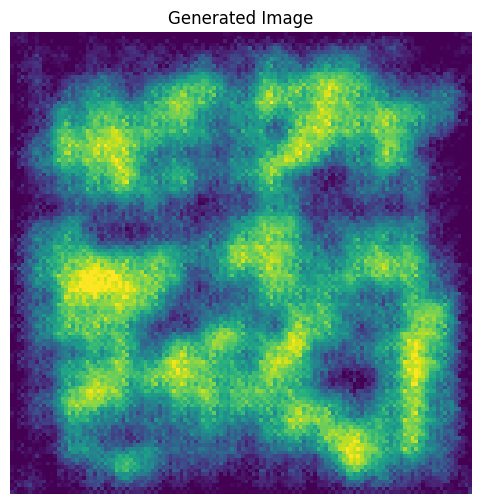

In [13]:
# Inference Cell — Latent Euler Integration + Decode at End

import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

compiled_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Settings ----
num_steps = 50
batch_size = 1
dt = 1.0 / num_steps

# ---- Get sample prompt ----
data_iter = iter(dataloader)
image_sample, prompt_sample = next(data_iter)

image_sample = image_sample[:batch_size].to(device)
prompt = prompt_sample[:batch_size].to(device)

# ---- Start from noise in IMAGE space ----
x_img = torch.randn_like(image_sample)

# ---- Encode once to latent space ----
with torch.no_grad():
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        x_latent = compiled_model.encoder(x_img)

# ---- Euler integration in LATENT space ----
with torch.no_grad():
    for step in tqdm(range(num_steps)):

        t = torch.ones((batch_size, 1), device=device) * ((step + 0.5) / num_steps)

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            v_latent = compiled_model(x_img, prompt, t)

        x_latent = x_latent + v_latent * dt

# ---- Decode ONCE at the end (autocast) ----
with torch.no_grad():
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        generated = compiled_model.decoder(x_latent)

# ---- Normalize to [0,1] ----
generated = (generated.clamp(-1, 1) + 1) / 2
generated = generated.detach().cpu()

# ---- Display ----
img = generated[0].permute(1, 2, 0).float().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Generated Image")
plt.show()